In [3]:
import re
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

In [1]:
cv_text = """
Experienced Python developer with machine learning and NLP skills.
Worked with FastAPI, REST APIs, and basic Docker.
"""

job_desc = """
We are looking for a Python developer with experience in Docker, CI/CD,
REST APIs, and machine learning.
"""

In [4]:
def text(text):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    return text

cv_clean = text(cv_text)
job_clean = text(job_desc)

print("CV Cleaned:\n", cv_clean)
print("\nJob Cleaned:\n", job_clean)

CV Cleaned:
 
experienced python developer with machine learning and nlp skills
worked with fastapi rest apis and basic docker


Job Cleaned:
 
we are looking for a python developer with experience in docker cicd
rest apis and machine learning



In [5]:
vectorizer = TfidfVectorizer()
tfidf = vectorizer.fit_transform([cv_clean, job_clean])

tfidf_score = cosine_similarity(tfidf[0], tfidf[1])[0][0]
print("TF-IDF Similarity:", tfidf_score)

TF-IDF Similarity: 0.444300609996757


In [6]:
model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode([cv_clean, job_clean])
sbert_score = cosine_similarity([embeddings[0]], [embeddings[1]])[0][0]

print("SBERT Similarity:", sbert_score)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SBERT Similarity: 0.7044129


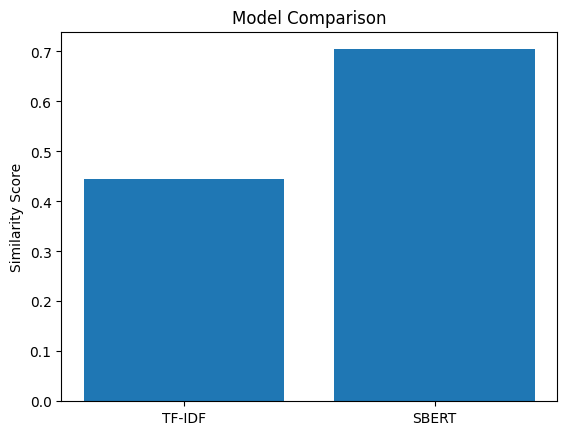

In [7]:
plt.figure()
plt.bar(["TF-IDF", "SBERT"], [tfidf_score, sbert_score])
plt.title("Model Comparison")
plt.ylabel("Similarity Score")
plt.show()

In [8]:
if sbert_score > tfidf_score:
    print("SBERT performs better due to semantic understanding.")
else:
    print("TF-IDF performs better for this example.")

SBERT performs better due to semantic understanding.
